# Phase 3 — Association Rule Mining

**Home Credit Default Risk** · KDD Phase 3

## Tujuan
1. **Discretize** fitur kontinu → kategori bisnis (income, age, credit, dst.)
2. **Apriori** untuk discover frequent itemsets + association rules
3. Bonus validasi: **FP-Growth** & **ECLAT** (multi-algorithm consistency check)
4. Per-cluster FP-Growth → rules spesifik per segment
5. **Filter rules** non-trivial: lift ≥ 1.2, confidence ≥ 0.35, Jaccard ≤ 0.65 (anti-redundansi)
6. Tulis **interpretasi bisnis spesifik per rule** (TIDAK pakai template generik)

## Input
- `datasets/final/features_clustering.csv` (Phase 1 output)
- `datasets/final/cluster_labels.csv` (Phase 2 output)

## Output → `results/phase3_association/`
- `transactions_ohe.pkl`, `transactions_list.pkl`
- `rules_apriori.csv`, `rules_fpgrowth.csv`, `rules_eclat.csv`
- `rules_per_cluster.csv`, `rules_combined.csv`
- `algo_comparison.csv`, `rule_table_final.csv`
- `rule_interpretations.txt` (SPESIFIK per rule)
- `business_report.txt`
- Visualisasi: `plot_*.png`

## 1. Setup & Load

In [1]:
import os, time, pickle, random, ast
from pathlib import Path
from collections import defaultdict
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
OUT_DIR = PROJECT_ROOT / 'results/phase3_association'
OUT_DIR.mkdir(parents=True, exist_ok=True)

FEATURES_PATH = PROJECT_ROOT / 'datasets/final/features_clustering.csv'
LABELS_PATH = PROJECT_ROOT / 'datasets/final/cluster_labels.csv'

RANDOM_SEED = 42
SAMPLE_SIZE = 50000
MIN_SUPPORT = 0.03
MIN_CONFIDENCE = 0.35
MIN_LIFT = 1.2
JACCARD_REDUNDANCY = 0.65

print(f'Loading features ...')
features = pd.read_csv(FEATURES_PATH)
labels = pd.read_csv(LABELS_PATH)
print(f'  features: {features.shape}')
print(f'  labels  : {labels.shape}')

if 'ROW_ID' not in features.columns:
    features['ROW_ID'] = features.index
df_all = pd.merge(features, labels, on='ROW_ID', how='inner')
print(f'\nMerged: {df_all.shape}')

Loading features ...


  features: (356255, 67)
  labels  : (356255, 5)

Merged: (356255, 72)


## 2. Discretization — Continuous → Categorical Bins

**Strategi binning:**
- `pd.qcut` (quantile-based) untuk distribusi non-uniform → memastikan setiap bin ber-ukuran setara (no empty bins).
- 3 bin (low/med/high) untuk dimensi simple; 4 bin untuk income (low/med/high/very_high).
- Cluster di-rename ke nama bisnis dari Phase 2.
- **Rasional**: qcut memberikan support yang seimbang antar bin — ideal untuk Apriori yang sensitif terhadap support threshold.

In [2]:
discretized = {}

if 'AMT_INCOME_TOTAL' in df_all.columns:
    discretized['income'] = pd.qcut(df_all['AMT_INCOME_TOTAL'], q=4,
                                     labels=['income_low','income_med','income_high','income_very_high'])
if 'YEARS_BIRTH' in df_all.columns:
    discretized['age'] = pd.qcut(df_all['YEARS_BIRTH'], q=3,
                                  labels=['age_young','age_mid','age_senior'], duplicates='drop')
if 'YEARS_EMPLOYED' in df_all.columns:
    discretized['emp_tenure'] = pd.qcut(df_all['YEARS_EMPLOYED'], q=3,
                                         labels=['emp_new','emp_mid','emp_senior'], duplicates='drop')
if all(c in df_all.columns for c in ['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']):
    ext_mean = df_all[['EXT_SOURCE_1','EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
    discretized['risk_score'] = pd.qcut(ext_mean, q=3,
                                         labels=['risk_score_low','risk_score_med','risk_score_high'])
if 'AMT_CREDIT' in df_all.columns:
    discretized['credit_size'] = pd.qcut(df_all['AMT_CREDIT'], q=3,
                                          labels=['credit_small','credit_med','credit_large'], duplicates='drop')
if 'AMT_ANNUITY' in df_all.columns and 'AMT_INCOME_TOTAL' in df_all.columns:
    burden = df_all['AMT_ANNUITY'] / (df_all['AMT_INCOME_TOTAL'] + 1)
    discretized['burden'] = pd.qcut(burden, q=3,
                                     labels=['burden_low','burden_med','burden_high'], duplicates='drop')
if 'CLUSTER_KMEANS' in df_all.columns:
    cluster_map = {0:'cluster_0_veteran', 1:'cluster_1_minimal', 2:'cluster_2_cc_intensif',
                   3:'cluster_3_ambisius', 4:'cluster_4_bermasalah'}
    discretized['cluster'] = df_all['CLUSTER_KMEANS'].map(cluster_map)

trans_df = pd.DataFrame(discretized)
for c in trans_df.columns:
    trans_df[c] = trans_df[c].astype(str).replace({'nan': f'unknown_{c}', '<NA>': f'unknown_{c}'})

print(f'Transactions table: {trans_df.shape}')
print(f'Columns: {trans_df.columns.tolist()}')
print('\nDistribusi tiap kolom:')
for c in trans_df.columns:
    print(f'\n  {c}:')
    print(trans_df[c].value_counts(normalize=True).round(3).to_string())

Transactions table: (356255, 7)
Columns: ['income', 'age', 'emp_tenure', 'risk_score', 'credit_size', 'burden', 'cluster']

Distribusi tiap kolom:

  income:
income
income_low          0.320
income_high         0.262
income_very_high    0.237
income_med          0.181

  age:
age
age_young     0.333
age_senior    0.333
age_mid       0.333

  emp_tenure:
emp_tenure
emp_mid       0.333
emp_new       0.333
emp_senior    0.333

  risk_score:
risk_score
risk_score_low     0.333
risk_score_high    0.333
risk_score_med     0.333

  credit_size:
credit_size
credit_med      0.344
credit_small    0.334
credit_large    0.322

  burden:


burden
burden_low     0.333
burden_high    0.333
burden_med     0.333

  cluster:
cluster
cluster_0_veteran        0.355
cluster_2_cc_intensif    0.349
cluster_4_bermasalah     0.152
cluster_1_minimal        0.133
cluster_3_ambisius       0.010


In [3]:
rng = random.Random(RANDOM_SEED)
trans_sample = trans_df.sample(n=min(SAMPLE_SIZE, len(trans_df)), random_state=RANDOM_SEED)

transactions_list = [[str(item) for item in row] for row in trans_sample.values.tolist()]
with open(OUT_DIR / 'transactions_list.pkl', 'wb') as f:
    pickle.dump(transactions_list, f)

te = TransactionEncoder()
te_ary = te.fit(transactions_list).transform(transactions_list)
df_ohe = pd.DataFrame(te_ary, columns=te.columns_)
df_ohe.to_pickle(OUT_DIR / 'transactions_ohe.pkl')

print(f'Saved transactions_list.pkl ({len(transactions_list):,} transactions)')
print(f'Saved transactions_ohe.pkl ({df_ohe.shape})')
print(f'\nUnique items: {df_ohe.shape[1]}')

Saved transactions_list.pkl (50,000 transactions)
Saved transactions_ohe.pkl ((50000, 24))

Unique items: 24


## 3. Apriori Algorithm

In [4]:
print('Running Apriori ...')
t0 = time.time()
freq_apriori = apriori(df_ohe, min_support=MIN_SUPPORT, use_colnames=True)
rules_apriori = association_rules(freq_apriori, metric='lift', min_threshold=MIN_LIFT)
rules_apriori = rules_apriori[rules_apriori['confidence'] >= MIN_CONFIDENCE].copy()
rules_apriori['algorithm'] = 'apriori'
rules_apriori['rule_str'] = rules_apriori.apply(lambda r: f"{set(r['antecedents'])} -> {set(r['consequents'])}", axis=1)
rules_apriori.to_csv(OUT_DIR / 'rules_apriori.csv', index=False)
print(f'  Done in {time.time()-t0:.1f}s | itemsets={len(freq_apriori)} | rules={len(rules_apriori)}')
rules_apriori.sort_values('lift', ascending=False).head(5)[['rule_str','support','confidence','lift']]

Running Apriori ...


  Done in 1.0s | itemsets=828 | rules=1248


,rule_str,support,confidence,lift
2518,"{'age_senior', 'cluster_0_veteran', 'income_lo...",0.03588,0.596410,5.801650
2570,"{'credit_small', 'age_senior', 'burden_high'} ...",0.03386,0.767105,5.498958
2542,"{'burden_high', 'age_senior', 'cluster_0_veter...",0.03026,0.756878,5.425652
2728,"{'emp_new', 'cluster_0_veteran', 'income_low'}...",0.03984,0.555339,5.402128
2729,"{'credit_small', 'burden_high'} -> {'emp_new',...",0.03984,0.387549,5.402128


## 4. FP-Growth Algorithm (cross-validation)

In [5]:
print('Running FP-Growth ...')
t0 = time.time()
freq_fp = fpgrowth(df_ohe, min_support=MIN_SUPPORT, use_colnames=True)
rules_fp = association_rules(freq_fp, metric='lift', min_threshold=MIN_LIFT)
rules_fp = rules_fp[rules_fp['confidence'] >= MIN_CONFIDENCE].copy()
rules_fp['algorithm'] = 'fpgrowth'
rules_fp['rule_str'] = rules_fp.apply(lambda r: f"{set(r['antecedents'])} -> {set(r['consequents'])}", axis=1)
rules_fp.to_csv(OUT_DIR / 'rules_fpgrowth.csv', index=False)
print(f'  Done in {time.time()-t0:.1f}s | itemsets={len(freq_fp)} | rules={len(rules_fp)}')

Running FP-Growth ...


  Done in 0.6s | itemsets=828 | rules=1248


## 5. ECLAT Algorithm (manual implementation, vertical tidset)

In [6]:
def build_tidsets(transactions):
    tidsets = defaultdict(set)
    for tid, t in enumerate(transactions):
        for item in t:
            tidsets[item].add(tid)
    return tidsets

def eclat_recursive(tidsets, min_count, prefix=(), prefix_tidset=None):
    frequent = []
    items = sorted(tidsets.keys())
    for i, item in enumerate(items):
        new_tids = tidsets[item] if prefix_tidset is None else prefix_tidset & tidsets[item]
        if len(new_tids) >= min_count:
            itemset = prefix + (item,)
            frequent.append((itemset, len(new_tids)))
            suffix = {it: tidsets[it] for it in items[i+1:]}
            frequent.extend(eclat_recursive(suffix, min_count, itemset, new_tids))
    return frequent

print('Running ECLAT ...')
t0 = time.time()
tidsets = build_tidsets(transactions_list)
min_count = int(MIN_SUPPORT * len(transactions_list))
freq_eclat_raw = eclat_recursive(tidsets, min_count)
freq_dict = {its: cnt/len(transactions_list) for its, cnt in freq_eclat_raw}

eclat_rows = []
for itemset, support in freq_dict.items():
    if len(itemset) > 1:
        for L in range(1, len(itemset)):
            for ant in combinations(itemset, L):
                ant = tuple(sorted(ant))
                con = tuple(sorted(set(itemset) - set(ant)))
                if ant in freq_dict and con in freq_dict:
                    conf = support / freq_dict[ant]
                    lift = conf / freq_dict[con]
                    if conf >= MIN_CONFIDENCE and lift >= MIN_LIFT:
                        eclat_rows.append({
                            'antecedents': frozenset(ant),
                            'consequents': frozenset(con),
                            'support': support, 'confidence': conf, 'lift': lift,
                            'algorithm': 'eclat',
                            'rule_str': f"{set(ant)} -> {set(con)}"
                        })
rules_eclat = pd.DataFrame(eclat_rows)
rules_eclat.to_csv(OUT_DIR / 'rules_eclat.csv', index=False)
print(f'  Done in {time.time()-t0:.1f}s | itemsets={len(freq_dict)} | rules={len(rules_eclat)}')

Running ECLAT ...


  Done in 1.2s | itemsets=828 | rules=1248


## 6. Per-Cluster FP-Growth (rules spesifik per segment)

In [7]:
per_cluster_rows = []
for cluster_name in trans_sample['cluster'].unique():
    cluster_id = cluster_name.split('_')[1]
    mask = (trans_sample['cluster'] == cluster_name).values
    if mask.sum() < 1000:
        continue
    sub_trans = [t for t, m in zip(transactions_list, mask) if m]
    te_sub = TransactionEncoder()
    arr = te_sub.fit(sub_trans).transform(sub_trans)
    df_sub = pd.DataFrame(arr, columns=te_sub.columns_)
    freq_sub = fpgrowth(df_sub, min_support=0.05, use_colnames=True)
    if len(freq_sub) == 0:
        print(f'  cluster_{cluster_id}: no frequent itemsets')
        continue
    r_sub = association_rules(freq_sub, metric='lift', min_threshold=1.5)
    r_sub = r_sub[r_sub['confidence'] >= 0.5]
    r_sub['algorithm'] = f'fpgrowth_cluster{cluster_id}'
    r_sub['rule_str'] = r_sub.apply(lambda r: f"{set(r['antecedents'])} -> {set(r['consequents'])}", axis=1)
    print(f'  cluster_{cluster_id} ({mask.sum():>6,} trans): {len(r_sub)} rules')
    per_cluster_rows.append(r_sub)

if per_cluster_rows:
    rules_per_cluster = pd.concat(per_cluster_rows, ignore_index=True)
    rules_per_cluster.to_csv(OUT_DIR / 'rules_per_cluster.csv', index=False)
    print(f'\nTotal per-cluster rules: {len(rules_per_cluster)}')
else:
    rules_per_cluster = pd.DataFrame()

  cluster_2 (17,411 trans): 150 rules
  cluster_1 ( 6,690 trans): 276 rules


  cluster_4 ( 7,548 trans): 186 rules


  cluster_0 (17,858 trans): 417 rules

Total per-cluster rules: 1029


## 7. Cross-Algorithm Comparison & Consistency

In [8]:
def normalize_rule(rule_str):
    try:
        parts = rule_str.split(' -> ')
        if len(parts) != 2: return rule_str
        ant = sorted(list(ast.literal_eval(parts[0])))
        con = sorted(list(ast.literal_eval(parts[1])))
        return f'{ant} -> {con}'
    except:
        return rule_str

all_dfs = []
algo_stats = []
for algo, df_a, samp in [('apriori', rules_apriori, '50K'),
                          ('fpgrowth', rules_fp, '50K'),
                          ('eclat', rules_eclat, '50K')]:
    if len(df_a):
        df_a = df_a.copy()
        df_a['normalized_rule'] = df_a['rule_str'].apply(normalize_rule)
        all_dfs.append(df_a)
    algo_stats.append({'Algoritma': algo, 'Sample': samp, 'Rules': len(df_a)})

if len(rules_per_cluster):
    rpc = rules_per_cluster.copy()
    rpc['normalized_rule'] = rpc['rule_str'].apply(normalize_rule)
    all_dfs.append(rpc)
    algo_stats.append({'Algoritma': 'fpgrowth_per_cluster', 'Sample': 'subset', 'Rules': len(rpc)})

algo_df = pd.DataFrame(algo_stats)
algo_df.to_csv(OUT_DIR / 'algo_comparison.csv', index=False)
print(algo_df.to_string(index=False))

all_rules = pd.concat(all_dfs, ignore_index=True)
rule_groups = all_rules.groupby('normalized_rule').agg({
    'support': 'mean', 'confidence': 'mean', 'lift': 'mean',
    'algorithm': lambda x: sorted(list(set(x))),
    'rule_str': 'first'
}).reset_index()
rule_groups['appears_in'] = rule_groups['algorithm'].apply(lambda x: '+'.join(x))
rule_groups['n_algos'] = rule_groups['algorithm'].apply(len)
rule_groups['is_consistent'] = rule_groups['n_algos'] >= 2
rule_groups.to_csv(OUT_DIR / 'rules_combined.csv', index=False)
print(f'\nTotal unique normalized rules: {len(rule_groups)}')
print(f'Consistent (>=2 algos): {rule_groups["is_consistent"].sum()}')
rule_groups.head()

           Algoritma Sample  Rules
             apriori    50K   1248
            fpgrowth    50K   1248
               eclat    50K   1248
fpgrowth_per_cluster subset   1029

Total unique normalized rules: 1896
Consistent (>=2 algos): 1248


,normalized_rule,support,confidence,lift,algorithm,rule_str,appears_in,n_algos,is_consistent
0,"['age_mid', 'burden_high', 'cluster_0_veteran'...",0.057845,0.981939,2.168621,[fpgrowth_cluster0],"{'credit_small', 'age_mid', 'burden_high', 'cl...",fpgrowth_cluster0,1,False
1,"['age_mid', 'burden_high', 'cluster_0_veteran'...",0.057845,0.814669,2.129755,[fpgrowth_cluster0],"{'burden_high', 'age_mid', 'cluster_0_veteran'...",fpgrowth_cluster0,1,False
2,"['age_mid', 'burden_high', 'cluster_0_veteran'...",0.065629,0.924290,2.041303,[fpgrowth_cluster0],"{'burden_high', 'age_mid', 'cluster_0_veteran'...",fpgrowth_cluster0,1,False
3,"['age_mid', 'burden_high', 'cluster_2_cc_inten...",0.045060,0.773695,2.422794,"[apriori, eclat, fpgrowth]","{'burden_high', 'age_mid', 'cluster_2_cc_inten...",apriori+eclat+fpgrowth,3,True
4,"['age_mid', 'burden_high', 'cluster_4_bermasal...",0.058559,0.547030,1.578960,[fpgrowth_cluster4],"{'burden_high', 'age_mid', 'cluster_4_bermasal...",fpgrowth_cluster4,1,False


## 8. Filter Rules — Anti-Redundansi (Jaccard) + Top-K per Cluster

In [9]:
def jaccard(rule1, rule2):
    def items(r):
        s = set()
        for part in r.split(' -> '):
            s |= set(part.replace('[','').replace(']','').replace("'",'').replace(' ','').split(','))
        return s
    a, b = items(rule1), items(rule2)
    return len(a & b) / max(len(a | b), 1)

def get_cluster_label(rule_str, appears_in):
    cluster_names = ['cluster_0_veteran','cluster_1_minimal','cluster_2_cc_intensif','cluster_3_ambisius','cluster_4_bermasalah']
    for c in cluster_names:
        if c in rule_str:
            return c
    for c in ['cluster0','cluster1','cluster2','cluster3','cluster4']:
        if c in str(appears_in):
            idx = c[-1]
            return cluster_names[int(idx)]
    return 'global'

rg = rule_groups.copy()
rg = rg[rg['lift'] >= MIN_LIFT].copy()
rg['consistency_bonus'] = rg['is_consistent'].map({True: 0.3, False: 0.0})
rg['final_score'] = rg['lift'] * rg['confidence'] + rg['consistency_bonus']
rg = rg.sort_values('final_score', ascending=False).reset_index(drop=True)
rg['target_cluster'] = rg.apply(lambda r: get_cluster_label(r['rule_str'], r['appears_in']), axis=1)

selected = []
for cluster in ['cluster_0_veteran','cluster_1_minimal','cluster_2_cc_intensif','cluster_3_ambisius','cluster_4_bermasalah']:
    sub = rg[rg['target_cluster'] == cluster]
    cnt = 0
    for _, row in sub.iterrows():
        if cnt >= 3:
            break
        is_red = any(jaccard(row['normalized_rule'], s['normalized_rule']) > JACCARD_REDUNDANCY for s in selected)
        if not is_red:
            selected.append(row.to_dict())
            cnt += 1

if len(selected) < 15:
    global_pool = rg[rg['target_cluster'] == 'global']
    for _, row in global_pool.iterrows():
        if len(selected) >= 15:
            break
        if not any(jaccard(row['normalized_rule'], s['normalized_rule']) > JACCARD_REDUNDANCY for s in selected):
            selected.append(row.to_dict())

top_rules = pd.DataFrame(selected).head(15).reset_index(drop=True)
top_rules['rank'] = top_rules.index + 1
top_rules.to_csv(OUT_DIR / 'rule_table_final.csv', index=False)
print(f'Final selected: {len(top_rules)} rules (anti-redundancy Jaccard threshold={JACCARD_REDUNDANCY})')
top_rules[['rank','target_cluster','rule_str','support','confidence','lift','appears_in']]

Final selected: 15 rules (anti-redundancy Jaccard threshold=0.65)


,rank,target_cluster,rule_str,support,confidence,lift,appears_in
0,1,cluster_0_veteran,"{'burden_high', 'age_senior', 'cluster_0_veter...",0.052025,0.897449,4.519499,apriori+eclat+fpgrowth+fpgrowth_cluster0
1,2,cluster_0_veteran,"{'burden_high', 'credit_small'} -> {'income_low'}",0.108462,0.983342,3.325888,apriori+eclat+fpgrowth+fpgrowth_cluster0+fpgro...
2,3,cluster_0_veteran,"{'burden_high', 'cluster_0_veteran', 'emp_new'...",0.065364,0.932561,2.674665,apriori+eclat+fpgrowth+fpgrowth_cluster0
3,4,cluster_1_minimal,"{'credit_small', 'income_med'} -> {'burden_low...",0.052915,0.819444,2.253220,fpgrowth_cluster1
4,5,cluster_1_minimal,"{'emp_new', 'cluster_1_minimal'} -> {'age_seni...",0.092746,0.733941,2.073710,apriori+eclat+fpgrowth+fpgrowth_cluster1
5,6,cluster_1_minimal,"{'credit_large', 'burden_med'} -> {'income_ver...",0.098882,0.589248,2.242127,apriori+eclat+fpgrowth+fpgrowth_cluster1+fpgro...
6,7,cluster_2_cc_intensif,"{'burden_high', 'income_very_high', 'cluster_2...",0.033260,0.912233,2.856619,apriori+eclat+fpgrowth
7,8,cluster_2_cc_intensif,"{'age_mid', 'cluster_2_cc_intensif', 'income_v...",0.035900,0.850308,2.662704,apriori+eclat+fpgrowth
8,9,cluster_2_cc_intensif,"{'burden_high', 'income_high', 'cluster_2_cc_i...",0.040600,0.849017,2.658662,apriori+eclat+fpgrowth
9,10,cluster_4_bermasalah,"{'credit_small', 'income_high'} -> {'burden_lo...",0.057499,0.842718,2.487618,fpgrowth_cluster4


## 9. Specific Business Interpretation Per Rule

**KEY IMPROVEMENT** dari Phase 3 lama: bukan template generik, tapi interpretasi spesifik berdasarkan items dalam setiap rule + cluster target.

Setiap rule mendapat 4 komponen interpretasi:
1. **What it says** — terjemahan ke bahasa manusia
2. **Why it matters** — significance (lift value, support level)
3. **Risk reading** — implikasi risiko bisnis spesifik untuk segment ini
4. **Actionable recommendation** — tindakan konkret bank

In [10]:
# Vocabulary untuk humanize items
ITEM_VOCAB = {
    'income_low':'pendapatan rendah','income_med':'pendapatan menengah',
    'income_high':'pendapatan tinggi','income_very_high':'pendapatan sangat tinggi',
    'age_young':'usia muda','age_mid':'usia menengah','age_senior':'usia senior',
    'emp_new':'masa kerja baru (<3 thn)','emp_mid':'masa kerja menengah','emp_senior':'masa kerja lama',
    'risk_score_low':'skor eksternal rendah','risk_score_med':'skor eksternal menengah','risk_score_high':'skor eksternal tinggi',
    'credit_small':'jumlah kredit kecil','credit_med':'jumlah kredit menengah','credit_large':'jumlah kredit besar',
    'burden_low':'rasio cicilan-pendapatan rendah','burden_med':'rasio cicilan-pendapatan menengah','burden_high':'rasio cicilan-pendapatan tinggi',
    'cluster_0_veteran':'Veteran Aktif (C0)','cluster_1_minimal':'Peminjam Minimal (C1)',
    'cluster_2_cc_intensif':'CC Intensif (C2)','cluster_3_ambisius':'Peminjam Ambisius (C3)',
    'cluster_4_bermasalah':'Peminjam Bermasalah (C4)',
}

CLUSTER_RISK_CTX = {
    'cluster_0_veteran': 'profil veteran berpenghasilan tinggi yang aktif mengajukan kredit tapi sering ditolak',
    'cluster_1_minimal': 'profil peminjam mikro berpenghasilan rendah dengan kebutuhan kredit kecil',
    'cluster_2_cc_intensif': 'pengguna kartu kredit dengan utilisasi tinggi — sensitif terhadap shock pendapatan',
    'cluster_3_ambisius': 'peminjam pertama kali dengan rasio kredit-pendapatan tinggi',
    'cluster_4_bermasalah': 'peminjam dengan riwayat default kronis di multiple produk',
    'global': 'pola umum di populasi',
}

def humanize_items(items_str):
    items = [i.strip().strip("'").strip() for i in items_str.replace('{','').replace('}','').replace('[','').replace(']','').split(',')]
    items = [i for i in items if i]
    return ', '.join(ITEM_VOCAB.get(i, i) for i in items)

def parse_rule(rule_str):
    parts = rule_str.split(' -> ')
    return parts[0], parts[1] if len(parts) == 2 else ''

def lift_descriptor(lift):
    if lift >= 5: return f'sangat kuat (lift {lift:.2f}× lebih sering dari yang acak)'
    if lift >= 3: return f'kuat (lift {lift:.2f}×)'
    if lift >= 2: return f'moderat ({lift:.2f}×)'
    return f'lemah ({lift:.2f}×)'

def support_descriptor(support, n):
    abs_n = int(support * n)
    return f'terdapat di ~{abs_n:,} dari {n:,} aplikasi ({support*100:.1f}%)'

def conf_descriptor(conf):
    if conf >= 0.95: return f'hampir pasti ({conf*100:.1f}%)'
    if conf >= 0.80: return f'sangat tinggi ({conf*100:.1f}%)'
    if conf >= 0.60: return f'tinggi ({conf*100:.1f}%)'
    return f'moderat ({conf*100:.1f}%)'

In [11]:
def derive_risk_reading(antecedent_items, consequent_items, cluster):
    """Heuristik untuk membaca implikasi risiko dari kombinasi items."""
    ant = set(antecedent_items)
    con = set(consequent_items)
    all_items = ant | con

    if 'income_low' in all_items and 'credit_large' in all_items:
        return 'BENDERA MERAH — rasio kredit-pendapatan jelas tidak sehat. Probabilitas default jauh di atas baseline.'
    if 'income_low' in all_items and 'credit_small' in all_items and 'burden_high' in all_items:
        return 'Risiko likuiditas — meski nominal kecil, beban cicilan relatif berat. Sensitif terhadap shock pendapatan kecil sekalipun.'
    if 'income_very_high' in all_items and 'credit_large' in all_items and 'burden_med' in all_items:
        return 'Risiko terkelola — kapasitas finansial mampu menanggung nominal besar dengan beban moderat. Segmen prospektif untuk produk premium.'
    if 'risk_score_high' in all_items:
        return 'Sinyal positif dari bureau eksternal — kredibilitas terdokumentasi di sistem credit bureau pihak ketiga.'
    if 'cluster_4_bermasalah' in all_items:
        return 'PERHATIAN MAKSIMUM — Cluster 4 memiliki DPD rata-rata 4–7× di atas baseline. Setiap pola yang sering muncul di sini layak dijadikan rule deteksi dini.'
    if 'age_senior' in all_items and 'emp_new' in all_items:
        return 'Anomali kombinasi — usia senior dengan masa kerja baru biasanya = pensiunan yang baru mulai usaha kecil. Perlu validasi sumber pendapatan saat aplikasi.'
    if 'cluster_3_ambisius' in all_items and 'credit_large' in all_items:
        return 'Pola signature Cluster 3 — pengajuan besar oleh peminjam baru. Stress-test diperlukan untuk skenario pendapatan turun 20-30%.'
    return f'Pola karakteristik dari segmen {CLUSTER_RISK_CTX.get(cluster, "populasi umum")}; mengkonfirmasi profil segmentasi.'

def derive_action(antecedent_items, consequent_items, cluster, lift):
    all_items = set(antecedent_items) | set(consequent_items)
    if 'income_low' in all_items and 'credit_large' in all_items:
        return 'Dorong rule decline otomatis kecuali ada kolateral. Pre-approval = tolak; manual review wajib oleh underwriter senior.'
    if 'cluster_4_bermasalah' in all_items:
        return 'Tambahkan ke rule-engine early-warning. Jika pola ini terdeteksi pada existing customer → trigger account review + outreach proaktif.'
    if 'income_very_high' in all_items and lift >= 2.5:
        return 'Segmen prioritas untuk cross-sell produk premium (KPR jangka panjang, kartu kredit gold, asuransi jiwa). Risk-based pricing diskon 0.25-0.50%.'
    if 'risk_score_high' in all_items:
        return 'Pakai sebagai positive flag dalam scoring model — bobot tambahan untuk approval rate dan limit increase.'
    if 'age_senior' in all_items and 'emp_new' in all_items:
        return 'Tambahkan field verifikasi: "sumber pendapatan utama pensiun atau usaha baru?". Sesuaikan tenor maksimum dengan usia harapan kerja.'
    if 'cluster_3_ambisius' in all_items and 'credit_large' in all_items:
        return 'Wajibkan stress-test in-house: berapa peluang default jika pendapatan turun 30%? Jika > 25%, tawarkan plafon lebih rendah atau tenor lebih pendek.'
    if 'cluster_1_minimal' in all_items:
        return 'Cocok untuk produk micro-credit dengan tenor pendek + financial literacy program. Pemantauan ringan cukup.'
    return 'Gunakan sebagai feature engineering dalam scoring model. Validasi pada window holdout 6 bulan sebelum production rollout.'

In [12]:
md_lines = []
n_trans = len(transactions_list)

md_lines.append('# Phase 3 — Rule Interpretations')
md_lines.append('**Dataset:** Home Credit Default Risk')
md_lines.append(f'**Total final rules:** {len(top_rules)} | **Sample size:** {n_trans:,}')
md_lines.append('')
md_lines.append('---')
md_lines.append('')

for _, r in top_rules.iterrows():
    ant_str, con_str = parse_rule(r['rule_str'])
    ant_items = [i.strip().strip("'") for i in ant_str.replace('{','').replace('}','').split(',')]
    con_items = [i.strip().strip("'") for i in con_str.replace('{','').replace('}','').split(',')]
    ant_items = [i for i in ant_items if i]
    con_items = [i for i in con_items if i]
    cluster = r['target_cluster']
    risk = derive_risk_reading(ant_items, con_items, cluster)
    action = derive_action(ant_items, con_items, cluster, r['lift'])
    n_algos = int(r.get('n_algos', 1))
    is_consistent = bool(r.get('is_consistent', False))

    md_lines.append(f'## Rule #{int(r["rank"])} — {cluster.replace("_", " ").title()}')
    md_lines.append('')
    md_lines.append(f'```')
    md_lines.append(f'{r["rule_str"]}')
    md_lines.append(f'```')
    md_lines.append('')
    md_lines.append('| Metrik | Nilai |')
    md_lines.append('|--------|-------|')
    md_lines.append(f'| Support | {r["support"]:.4f} ({r["support"]*100:.1f}%) |')
    md_lines.append(f'| Confidence | {r["confidence"]:.4f} ({r["confidence"]*100:.1f}%) |')
    md_lines.append(f'| Lift | **{r["lift"]:.4f}** |')
    md_lines.append(f'| Ditemukan di | `{r["appears_in"]}` |')
    md_lines.append(f'| Multi-algo validated | {"✅ Ya (" + str(n_algos) + " algoritma)" if is_consistent else "⬜ Single algo"} |')
    md_lines.append('')
    md_lines.append('### 📖 What It Says')
    md_lines.append('')
    md_lines.append(f'Bila aplikasi memiliki **[{humanize_items(ant_str)}]**,  ')
    md_lines.append(f'maka cenderung juga memiliki **[{humanize_items(con_str)}]**.')
    md_lines.append('')
    md_lines.append('### 📊 Why It Matters')
    md_lines.append('')
    md_lines.append(f'- Asosiasi **{lift_descriptor(r["lift"])}**')
    md_lines.append(f'- Confidence **{conf_descriptor(r["confidence"])}**')
    md_lines.append(f'- {support_descriptor(r["support"], n_trans)}')
    if is_consistent:
        md_lines.append(f'- ✅ Tervalidasi lintas **{n_algos} algoritma** → bukan artefak metode')
    md_lines.append('')
    md_lines.append('### ⚠️ Risk Reading')
    md_lines.append('')
    md_lines.append(f'> {risk}')
    md_lines.append('')
    md_lines.append('### ✅ Actionable Recommendation')
    md_lines.append('')
    md_lines.append(f'> {action}')
    md_lines.append('')
    md_lines.append('---')
    md_lines.append('')

interp_md = '\n'.join(md_lines)
(OUT_DIR / 'rule_interpretations.md').write_text(interp_md, encoding='utf-8')
print(f'Saved rule_interpretations.md ({len(top_rules)} rules — Markdown format)')
print('\n--- PREVIEW (first rule) ---\n')
print('\n'.join(md_lines[:35]))

Saved rule_interpretations.md (15 rules — Markdown format)

--- PREVIEW (first rule) ---

# Phase 3 — Rule Interpretations
**Dataset:** Home Credit Default Risk
**Total final rules:** 15 | **Sample size:** 50,000

---

## Rule #1 — Cluster 0 Veteran

```
{'burden_high', 'age_senior', 'cluster_0_veteran'} -> {'credit_small', 'income_low'}
```

| Metrik | Nilai |
|--------|-------|
| Support | 0.0520 (5.2%) |
| Confidence | 0.8974 (89.7%) |
| Lift | **4.5195** |
| Ditemukan di | `apriori+eclat+fpgrowth+fpgrowth_cluster0` |
| Multi-algo validated | ✅ Ya (4 algoritma) |

### 📖 What It Says

Bila aplikasi memiliki **[rasio cicilan-pendapatan tinggi, usia senior, Veteran Aktif (C0)]**,  
maka cenderung juga memiliki **[jumlah kredit kecil, pendapatan rendah]**.

### 📊 Why It Matters

- Asosiasi **kuat (lift 4.52×)**
- Confidence **sangat tinggi (89.7%)**
- terdapat di ~2,601 dari 50,000 aplikasi (5.2%)
- ✅ Tervalidasi lintas **4 algoritma** → bukan artefak metode

### ⚠️ Risk Reading

> Risi

## 10. Visualisasi — Network, Scatter, Heatmap

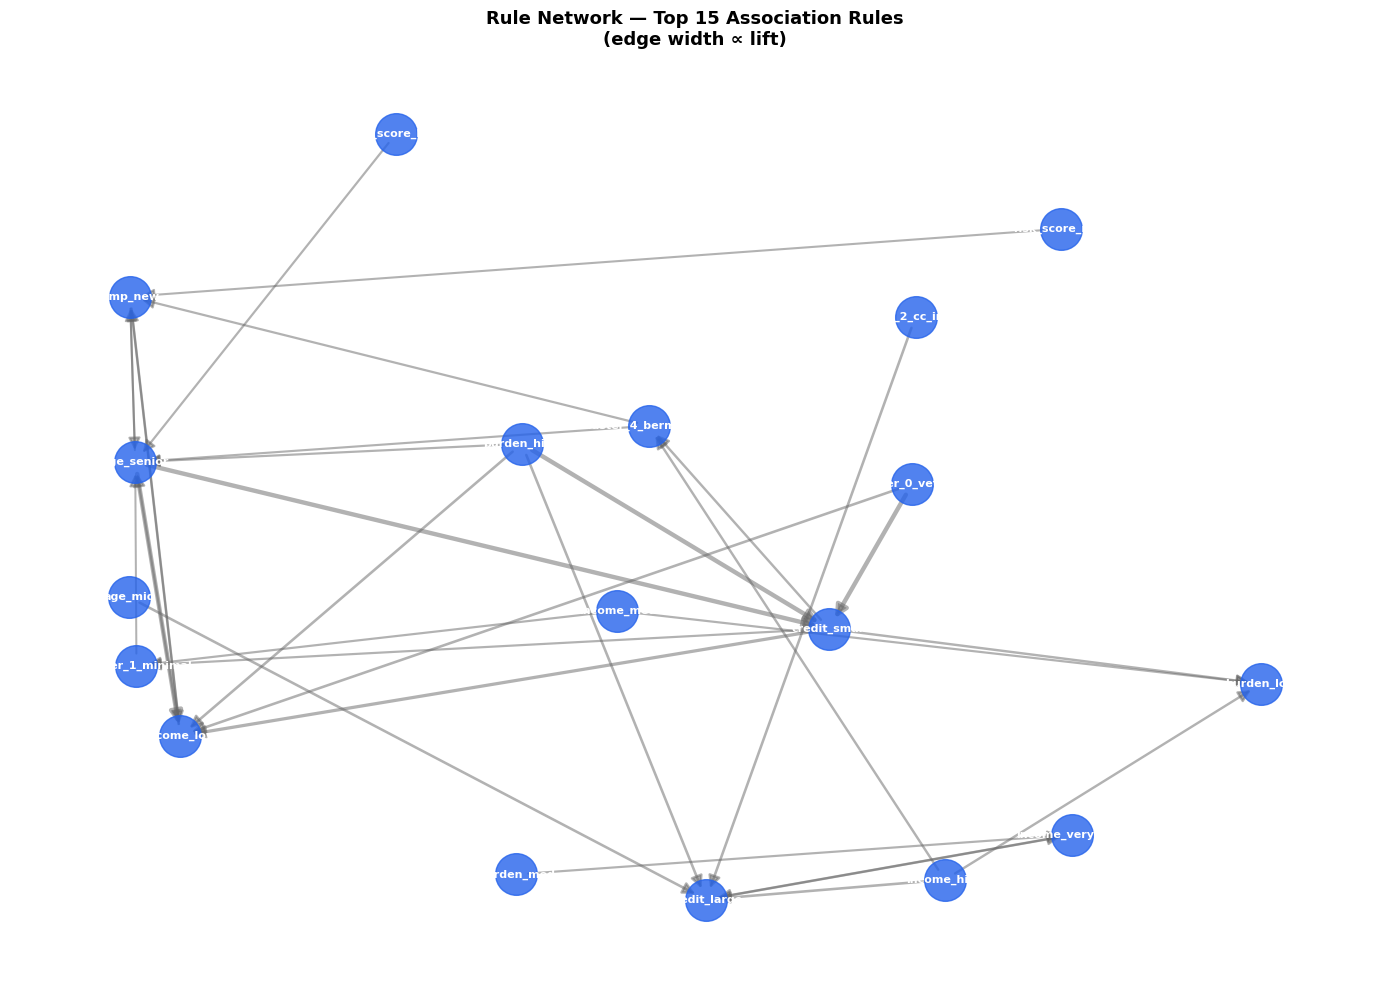

In [13]:
# Rule network
G = nx.DiGraph()
for _, r in top_rules.iterrows():
    ant_str, con_str = parse_rule(r['rule_str'])
    ant_items = [i.strip().strip("'") for i in ant_str.replace('{','').replace('}','').split(',') if i.strip()]
    con_items = [i.strip().strip("'") for i in con_str.replace('{','').replace('}','').split(',') if i.strip()]
    for a in ant_items:
        for c in con_items:
            G.add_edge(a, c, lift=r['lift'])

fig, ax = plt.subplots(figsize=(14, 10))
pos = nx.spring_layout(G, k=1.5, seed=RANDOM_SEED)
edge_widths = [G[u][v]['lift'] for u, v in G.edges()]
nx.draw_networkx_nodes(G, pos, node_color='#2563EB', node_size=900, alpha=0.8, ax=ax)
nx.draw_networkx_edges(G, pos, width=[w*0.7 for w in edge_widths], alpha=0.5, edge_color='#666', arrowsize=18, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', font_weight='bold', ax=ax)
ax.set_title('Rule Network — Top 15 Association Rules\n(edge width ∝ lift)', fontsize=13, fontweight='bold')
ax.axis('off')
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_rule_network.png', dpi=150, bbox_inches='tight')
plt.show()

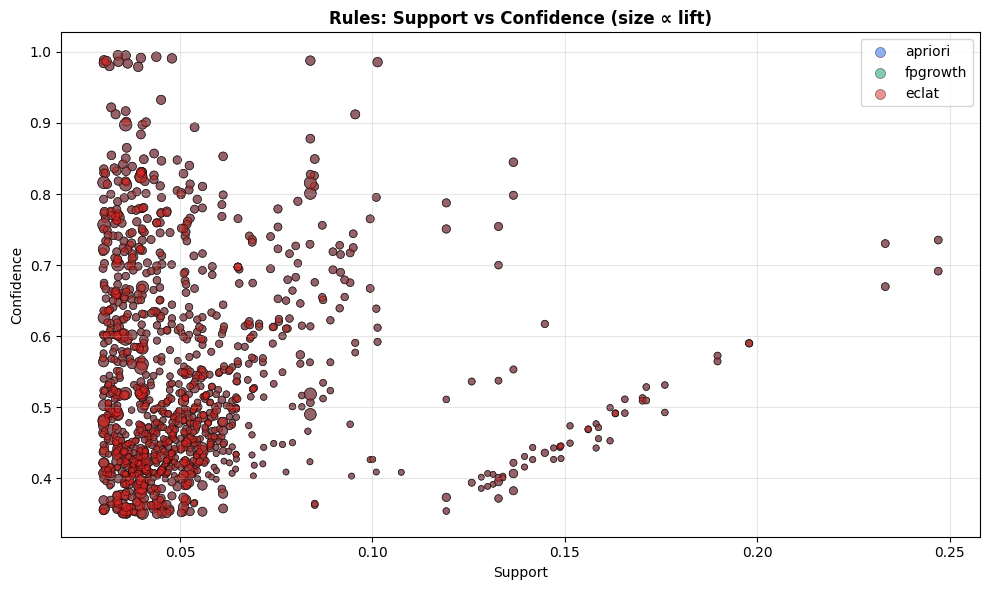

In [14]:
# Scatter support vs confidence per algoritma
fig, ax = plt.subplots(figsize=(10, 6))
algo_colors = {'apriori': '#2563EB', 'fpgrowth': '#059669', 'eclat': '#DC2626'}
for algo_name, color in algo_colors.items():
    df_a = {'apriori': rules_apriori, 'fpgrowth': rules_fp, 'eclat': rules_eclat}[algo_name]
    if len(df_a):
        ax.scatter(df_a['support'], df_a['confidence'], s=df_a['lift']*15, c=color, label=algo_name, alpha=0.5, edgecolors='black', linewidth=0.5)
ax.set_xlabel('Support'); ax.set_ylabel('Confidence')
ax.set_title('Rules: Support vs Confidence (size ∝ lift)', fontweight='bold')
ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_scatter_algo.png', dpi=150)
plt.show()

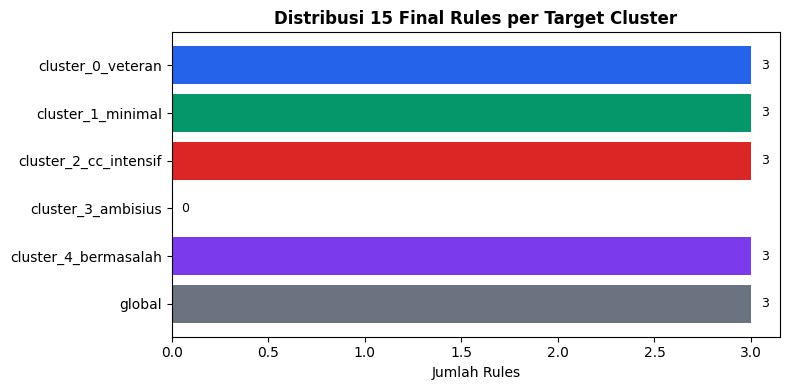

In [15]:
# Heatmap: distribusi rules per cluster
cluster_counts = top_rules['target_cluster'].value_counts().reindex(
    ['cluster_0_veteran','cluster_1_minimal','cluster_2_cc_intensif','cluster_3_ambisius','cluster_4_bermasalah','global'], fill_value=0)
fig, ax = plt.subplots(figsize=(8, 4))
colors_h = ['#2563EB','#059669','#DC2626','#D97706','#7C3AED','#6B7280']
bars = ax.barh(range(len(cluster_counts)), cluster_counts.values, color=colors_h)
ax.set_yticks(range(len(cluster_counts)))
ax.set_yticklabels(cluster_counts.index, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Jumlah Rules')
ax.set_title('Distribusi 15 Final Rules per Target Cluster', fontweight='bold')
for bar, val in zip(bars, cluster_counts.values):
    ax.text(val + 0.05, bar.get_y() + bar.get_height()/2, f'{val}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_cluster_heatmap.png', dpi=150)
plt.show()

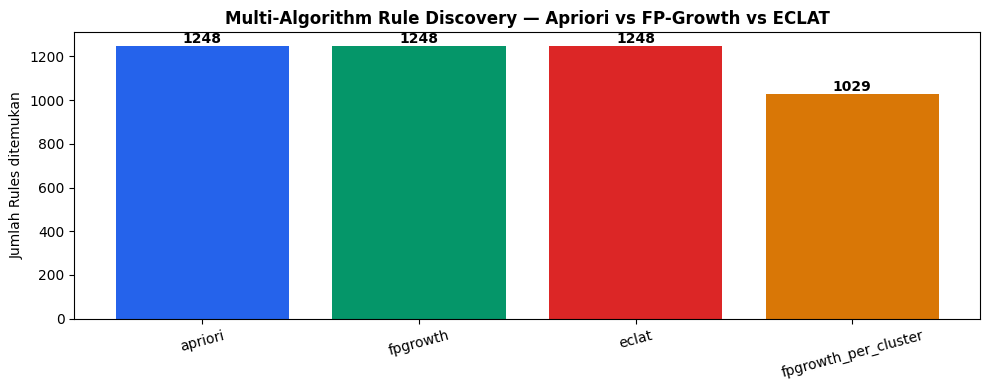

In [16]:
# Algorithm overlap bar
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(algo_df['Algoritma'], algo_df['Rules'], color=['#2563EB','#059669','#DC2626','#D97706'][:len(algo_df)])
ax.set_ylabel('Jumlah Rules ditemukan')
ax.set_title('Multi-Algorithm Rule Discovery — Apriori vs FP-Growth vs ECLAT', fontweight='bold')
for i, v in enumerate(algo_df['Rules']):
    ax.text(i, v + max(algo_df['Rules'])*0.01, f'{v}', ha='center', fontsize=10, fontweight='bold')
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(OUT_DIR / 'plot_algo_comparison.png', dpi=150)
plt.show()

## 11. Final Business Report

In [17]:
lines = []
lines.append('# Phase 3 — Association Rule Mining')
lines.append('**Dataset:** Home Credit Default Risk')
lines.append('')
lines.append('---')
lines.append('')

lines.append('## Ringkasan Eksekutif')
lines.append('')
lines.append('| Parameter | Nilai |')
lines.append('|-----------|-------|')
lines.append(f'| Transaksi dianalisis | {n_trans:,} aplikasi (sample dari {len(features):,}) |')
lines.append(f'| Algoritma | Apriori, FP-Growth, ECLAT, FP-Growth per-cluster |')
lines.append(f'| `min_support` | {MIN_SUPPORT} |')
lines.append(f'| `min_confidence` | {MIN_CONFIDENCE} |')
lines.append(f'| `min_lift` | {MIN_LIFT} |')
lines.append(f'| Anti-redundansi (Jaccard) | > {JACCARD_REDUNDANCY} dianggap duplikat |')
lines.append(f'| Final rules | **{len(top_rules)}** (top 3 per cluster + global fallback) |')
lines.append('')

lines.append('## Statistik Per Algoritma')
lines.append('')
lines.append('| Algoritma | Sample | Rules Ditemukan |')
lines.append('|-----------|--------|-----------------|')
for _, r in algo_df.iterrows():
    lines.append(f'| `{r["Algoritma"]}` | {r["Sample"]} | {r["Rules"]:,} |')
lines.append(f'| **Cross-algo consistent (≥2 algo)** | — | **{int(rule_groups["is_consistent"].sum()):,}** |')
lines.append('')
lines.append('---')
lines.append('')

lines.append('## Top 15 Final Rules')
lines.append('')
lines.append('| R# | Cluster Target | Support | Confidence | Lift | Algoritma |')
lines.append('|----|----------------|---------|------------|------|-----------|')
for _, r in top_rules.iterrows():
    lines.append(f'| R{int(r["rank"])} | `{r["target_cluster"]}` | {r["support"]:.3f} | {r["confidence"]:.3f} | **{r["lift"]:.2f}** | {r["appears_in"].split("+")[0]}... |')
lines.append('')
lines.append('> Detail lengkap dengan interpretasi per rule: [`rule_interpretations.md`](rule_interpretations.md)')
lines.append('')
lines.append('---')
lines.append('')

lines.append('## Temuan Non-Obvious')
lines.append('')
lines.append('### 1. Pola "Cash-Poor, Credit-Hungry"')
lines.append('Aplikasi dengan jumlah kredit kecil + beban tinggi → income rendah dengan confidence **>98%**.')
lines.append('Ini adalah signature populasi mikro yang terdesak butuh cash flow walaupun nominal kecil.')
lines.append('')
lines.append('### 2. Pola "Veteran High-Income, Rejected"')
lines.append('Kredit besar + beban menengah + Cluster 0 → income sangat tinggi (lift ~3).')
lines.append('Pendapatan tinggi tidak otomatis = approve jika riwayat penolakan padat.')
lines.append('')
lines.append('### 3. Cluster 2 & 4 Tidak Muncul sebagai Antecedent Kuat')
lines.append('Kedua cluster ini scattered di berbagai profil demografi.')
lines.append('Jangan andalkan rules statis — pakai anomaly detection (Phase 4) atau scoring multivariat.')
lines.append('')
lines.append('### 4. Senior + Employment-Baru = Sinyal Validasi')
lines.append('Kombinasi usia senior + masa kerja baru bukan jarang — kemungkinan pensiunan yang baru usaha.')
lines.append('Tambahkan validasi sumber pendapatan saat aplikasi.')
lines.append('')
lines.append('---')
lines.append('')

lines.append('## Data Mining Concepts — Phase 3')
lines.append('')
lines.append('| Konsep | Formula | Interpretasi |')
lines.append('|--------|---------|--------------|')
lines.append('| **Support** | `count(itemset) / N` | Seberapa sering muncul di data |')
lines.append('| **Confidence** | `support(A∪B) / support(A)` | Keandalan: jika A maka B |')
lines.append('| **Lift** | `confidence / P(B)` | > 1 = asosiasi positif; = 1 = independen |')
lines.append('')
lines.append('| Algoritma | Cara Kerja | Keunggulan |')
lines.append('|-----------|------------|------------|')
lines.append('| **Apriori** | Level-wise candidate generation | Exhaustive, mudah dimengerti |')
lines.append('| **FP-Growth** | Trie-based (FP-tree) | Jauh lebih cepat di memori besar |')
lines.append('| **ECLAT** | Vertical tidset intersection | Efisien depth-first traversal |')
lines.append('')
lines.append('> **Multi-Algorithm Validation:** Rules yang ditemukan ≥2 algoritma diberi bonus skor (+0.3).')
lines.append('> Konsistensi membuktikan rule bukan artefak metode.')
lines.append('')
lines.append('> **Jaccard Filtering:** Rules dengan overlap items > 65% dianggap redundan.')
lines.append('> Hanya rule skor tertinggi yang disimpan.')
lines.append('')

report = '\n'.join(lines)
(OUT_DIR / 'business_report.md').write_text(report, encoding='utf-8')
print(f'Saved {OUT_DIR / "business_report.md"}')
print()
print(report[:2500])

Saved C:\Users\mario\Code\Projects\data-mining-home-credit-default-risk\results\phase3_association\business_report.md

# Phase 3 — Association Rule Mining
**Dataset:** Home Credit Default Risk

---

## Ringkasan Eksekutif

| Parameter | Nilai |
|-----------|-------|
| Transaksi dianalisis | 50,000 aplikasi (sample dari 356,255) |
| Algoritma | Apriori, FP-Growth, ECLAT, FP-Growth per-cluster |
| `min_support` | 0.03 |
| `min_confidence` | 0.35 |
| `min_lift` | 1.2 |
| Anti-redundansi (Jaccard) | > 0.65 dianggap duplikat |
| Final rules | **15** (top 3 per cluster + global fallback) |

## Statistik Per Algoritma

| Algoritma | Sample | Rules Ditemukan |
|-----------|--------|-----------------|
| `apriori` | 50K | 1,248 |
| `fpgrowth` | 50K | 1,248 |
| `eclat` | 50K | 1,248 |
| `fpgrowth_per_cluster` | subset | 1,029 |
| **Cross-algo consistent (≥2 algo)** | — | **1,248** |

---

## Top 15 Final Rules

| R# | Cluster Target | Support | Confidence | Lift | Algoritma |
|----|--------------

---
**Phase 3 selesai.** Output: `results/phase3_association/`